In [808]:
import pandas as pd
df = pd.read_pickle('cleaned_one.pkl')
import matplotlib.pyplot as plt

df.head()

,age,region,primary_diagnosis,treatment_type,insurance_type,discharge_disposition,readmission_risk_score,label,prev_readmit_group,comorbidities_group,los_group,medications_group,followup_visits_group
0,66,South,Diabetes,Interventional,Medicare,Home Health,0.92,1,1,five or more,6 to 8,8 to 14,5 or more
1,55,South,Diabetes,Interventional,Private,Home Health,0.88,1,2,four,6 to 8,6,4
2,69,West,Hypertension,Medical,Medicare,Skilled Nursing,0.97,1,2,five or more,6 to 8,8 to 14,5 or more
3,83,South,Stroke,Medical,Medicare,Skilled Nursing,0.97,1,2,five or more,9+,8 to 14,4
4,54,North,Stroke,Medical,Uninsured,Home Health,0.83,1,1,four,9+,6,2


In [809]:
df.groupby('region')['label'].mean()

region
Central    0.790453
East       0.772418
North      0.788575
South      0.767185
West       0.752299
Name: label, dtype: float64

In [810]:
df.groupby('primary_diagnosis')['label'].mean()

primary_diagnosis
Appendicitis      0.711610
COPD              0.868697
Diabetes          0.705442
Fracture          0.702765
Heart Failure     0.858561
Hypertension      0.696387
Influenza         0.686695
Kidney Disease    0.832949
Pneumonia         0.738824
Sepsis            0.869215
Stroke            0.852775
Name: label, dtype: float64

In [811]:
df.groupby('treatment_type')['label'].mean()

treatment_type
Conservative      0.817346
Interventional    0.766687
Medical           0.768952
Surgical          0.768109
Name: label, dtype: float64

In [812]:
df.groupby('insurance_type')['label'].mean()

insurance_type
Medicaid     0.705882
Medicare     0.953580
Private      0.660550
Uninsured    0.761139
Name: label, dtype: float64

In [813]:
df.groupby('discharge_disposition')['label'].mean()

discharge_disposition
Home               0.340694
Home Health        0.758450
Rehab              0.340000
Skilled Nursing    0.929847
Name: label, dtype: float64

In [814]:
# drop region
df = df.drop(columns=['region', 'treatment_type'])

In [815]:
df.head()

,age,primary_diagnosis,insurance_type,discharge_disposition,readmission_risk_score,label,prev_readmit_group,comorbidities_group,los_group,medications_group,followup_visits_group
0,66,Diabetes,Medicare,Home Health,0.92,1,1,five or more,6 to 8,8 to 14,5 or more
1,55,Diabetes,Private,Home Health,0.88,1,2,four,6 to 8,6,4
2,69,Hypertension,Medicare,Skilled Nursing,0.97,1,2,five or more,6 to 8,8 to 14,5 or more
3,83,Stroke,Medicare,Skilled Nursing,0.97,1,2,five or more,9+,8 to 14,4
4,54,Stroke,Uninsured,Home Health,0.83,1,1,four,9+,6,2


In [816]:
risk_group = df.groupby('readmission_risk_score')['label'].mean()
risk_group.describe()

count    85.000000
mean      0.524493
std       0.294294
min       0.000000
25%       0.230769
50%       0.541667
75%       0.764228
max       0.964798
Name: label, dtype: float64

In [817]:
data = df.groupby('readmission_risk_score')['label'].agg(['count', 'mean'])
print(data.to_string())

                        count      mean
readmission_risk_score                 
0.07                        6  0.166667
0.11                        2  0.000000
0.12                        9  0.000000
0.14                       32  0.218750
0.15                       10  0.100000
0.16                        7  0.142857
0.18                       53  0.207547
0.19                       11  0.181818
0.20                        6  0.166667
0.21                        3  0.000000
0.22                       45  0.200000
0.23                       10  0.400000
0.24                       13  0.230769
0.25                        8  0.000000
0.26                       23  0.217391
0.27                        9  0.111111
0.28                        6  0.500000
0.29                       10  0.200000
0.30                        9  0.444444
0.31                        5  0.000000
0.32                       42  0.190476
0.33                       15  0.200000
0.34                        2  0.000000


In [818]:
df['risk_score_bin'] = None
group_one_range = ((df['readmission_risk_score'] >= 0.07) & (df['readmission_risk_score'] <= 0.34))

group_two_range = ((df['readmission_risk_score'] >= 0.36) & (df['readmission_risk_score'] <= 0.49))

group_three_range = ((df['readmission_risk_score'] >= 0.50) & (df['readmission_risk_score'] <= 0.59))

group_four_range = ((df['readmission_risk_score'] >= 0.60) & (df['readmission_risk_score'] <= 0.66))

group_five_range = ((df['readmission_risk_score'] >= 0.67) & (df['readmission_risk_score'] <= 0.76))

group_six_range = ((df['readmission_risk_score'] >= 0.77) & (df['readmission_risk_score'] <= 0.86))

group_seven_range = df['readmission_risk_score'] >= 0.87

In [819]:
df.loc[group_one_range, 'risk_score_bin'] = 1
df.loc[group_two_range, 'risk_score_bin'] = 2
df.loc[group_three_range, 'risk_score_bin'] = 3
df.loc[group_four_range, 'risk_score_bin'] = 4
df.loc[group_five_range, 'risk_score_bin'] = 5
df.loc[group_six_range, 'risk_score_bin'] = 6
df.loc[group_seven_range, 'risk_score_bin'] = 7

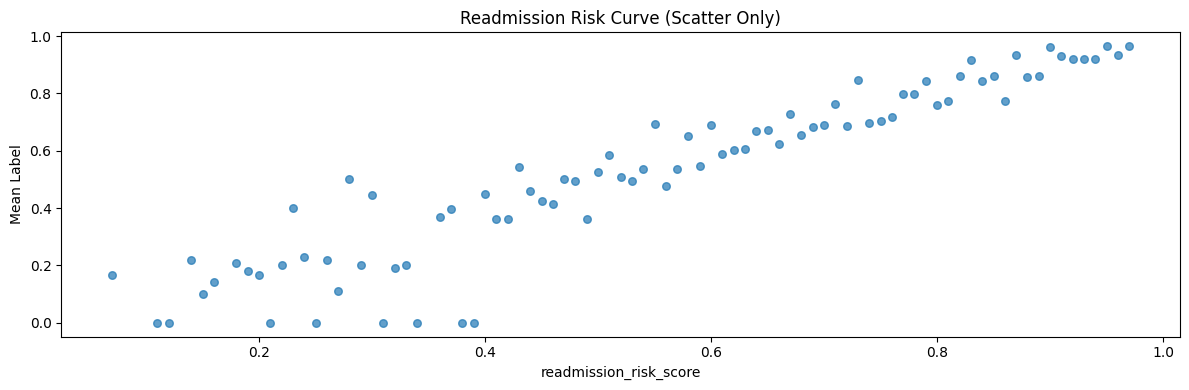

In [820]:
import matplotlib.pyplot as plt

# Compute the mean label at each risk score
risk_curve = df.groupby('readmission_risk_score')['label'].mean()

plt.figure(figsize=(12,4))

# Scatter plot instead of a line
plt.scatter(risk_curve.index, risk_curve.values, s=30, alpha=0.7)

plt.xlabel("readmission_risk_score")
plt.ylabel("Mean Label")
plt.title("Readmission Risk Curve (Scatter Only)")

plt.tight_layout()
plt.show()


In [821]:
df.head()


,age,primary_diagnosis,insurance_type,discharge_disposition,readmission_risk_score,label,prev_readmit_group,comorbidities_group,los_group,medications_group,followup_visits_group,risk_score_bin
0,66,Diabetes,Medicare,Home Health,0.92,1,1,five or more,6 to 8,8 to 14,5 or more,7
1,55,Diabetes,Private,Home Health,0.88,1,2,four,6 to 8,6,4,7
2,69,Hypertension,Medicare,Skilled Nursing,0.97,1,2,five or more,6 to 8,8 to 14,5 or more,7
3,83,Stroke,Medicare,Skilled Nursing,0.97,1,2,five or more,9+,8 to 14,4,7
4,54,Stroke,Uninsured,Home Health,0.83,1,1,four,9+,6,2,6


In [822]:
bins = df.groupby('risk_score_bin')['label'].agg(['count', 'mean'])
bins

,count,mean
risk_score_bin,,
1,336,0.196429
2,832,0.408654
3,594,0.553872
4,491,0.631365
5,1069,0.713751
6,733,0.824011
7,3945,0.955894


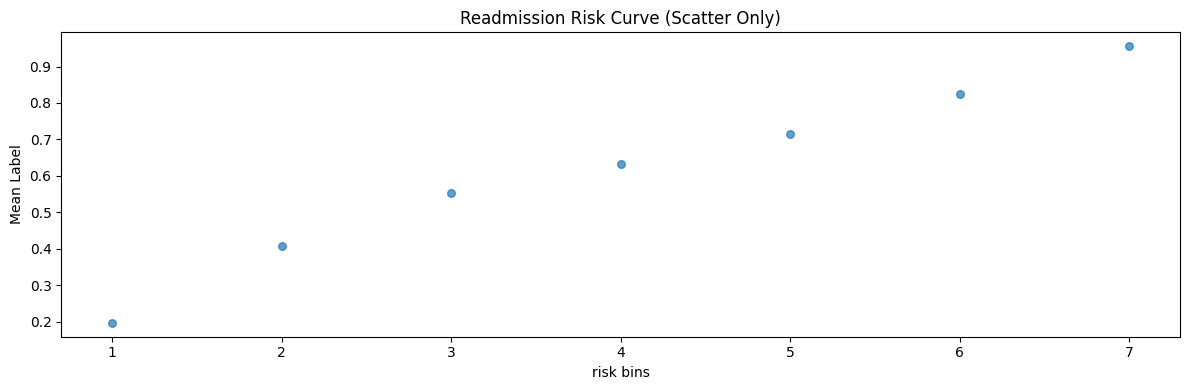

In [823]:
import matplotlib.pyplot as plt

# Compute the mean label at each risk score
risk_curve = df.groupby('risk_score_bin')['label'].mean()

plt.figure(figsize=(12,4))

# Scatter plot instead of a line
plt.scatter(risk_curve.index, risk_curve.values, s=30, alpha=0.7)

plt.xlabel("risk bins")
plt.ylabel("Mean Label")
plt.title("Readmission Risk Curve (Scatter Only)")

plt.tight_layout()
plt.show()

In [824]:
df.head()

,age,primary_diagnosis,insurance_type,discharge_disposition,readmission_risk_score,label,prev_readmit_group,comorbidities_group,los_group,medications_group,followup_visits_group,risk_score_bin
0,66,Diabetes,Medicare,Home Health,0.92,1,1,five or more,6 to 8,8 to 14,5 or more,7
1,55,Diabetes,Private,Home Health,0.88,1,2,four,6 to 8,6,4,7
2,69,Hypertension,Medicare,Skilled Nursing,0.97,1,2,five or more,6 to 8,8 to 14,5 or more,7
3,83,Stroke,Medicare,Skilled Nursing,0.97,1,2,five or more,9+,8 to 14,4,7
4,54,Stroke,Uninsured,Home Health,0.83,1,1,four,9+,6,2,6


In [825]:
df2 = df.copy()
df2 = df2.drop(columns=['readmission_risk_score'])

In [826]:
df2.head()

,age,primary_diagnosis,insurance_type,discharge_disposition,label,prev_readmit_group,comorbidities_group,los_group,medications_group,followup_visits_group,risk_score_bin
0,66,Diabetes,Medicare,Home Health,1,1,five or more,6 to 8,8 to 14,5 or more,7
1,55,Diabetes,Private,Home Health,1,2,four,6 to 8,6,4,7
2,69,Hypertension,Medicare,Skilled Nursing,1,2,five or more,6 to 8,8 to 14,5 or more,7
3,83,Stroke,Medicare,Skilled Nursing,1,2,five or more,9+,8 to 14,4,7
4,54,Stroke,Uninsured,Home Health,1,1,four,9+,6,2,6


In [827]:
df2.to_pickle('cleaned_two.pkl')